In [ ]:
#Electric Motor Speed Prediction Project Plan
#Objective:
#Predict motor speed based on various sensor data from a Permanent Magnet Synchronous Motor (PMSM) deployed on a test bench. 
#The goal is to develop accurate models and deploy them for real-world applications, providing insights into motor behavior.

In [ ]:
#Model Building
#SVM

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r'D:\HI448116_Santosh_Karpe\FY25\DOCS\III\Ass\ASA - SK\Dataset and Objective-20250118T164825Z-001\Dataset and Objective\temperature_data (1).csv')

# Display the first few rows to understand its structure
df.head()

,ambient,coolant,u_d,u_q,motor_speed,torque,i_d,i_q,pm,stator_yoke,stator_tooth,stator_winding,profile_id
0,-0.752143,-1.118446,0.327935,-1.297858,-1.222428,-0.250182,1.029572,-0.245860,-2.522071,-1.831422,-2.066143,-2.018033,4
1,-0.771263,-1.117021,0.329665,-1.297686,-1.222429,-0.249133,1.029509,-0.245832,-2.522418,-1.830969,-2.064859,-2.017631,4
2,-0.782892,-1.116681,0.332771,-1.301822,-1.222428,-0.249431,1.029448,-0.245818,-2.522673,-1.830400,-2.064073,-2.017343,4
3,-0.780935,-1.116764,0.333700,-1.301852,-1.222430,-0.248636,1.032845,-0.246955,-2.521639,-1.830333,-2.063137,-2.017632,4
4,-0.774043,-1.116775,0.335206,-1.303118,-1.222429,-0.248701,1.031807,-0.246610,-2.521900,-1.830498,-2.062795,-2.018145,4


In [ ]:
#SVM

In [3]:
# Show the first few rows of the dataset to understand its structure
print(df.head())

# Check for missing values
print(df.isnull().sum())

# Check the data types of each column
print(df.dtypes)

# Basic summary statistics
print(df.describe())

    ambient   coolant       u_d       u_q  motor_speed    torque       i_d  \
0 -0.752143 -1.118446  0.327935 -1.297858    -1.222428 -0.250182  1.029572   
1 -0.771263 -1.117021  0.329665 -1.297686    -1.222429 -0.249133  1.029509   
2 -0.782892 -1.116681  0.332771 -1.301822    -1.222428 -0.249431  1.029448   
3 -0.780935 -1.116764  0.333700 -1.301852    -1.222430 -0.248636  1.032845   
4 -0.774043 -1.116775  0.335206 -1.303118    -1.222429 -0.248701  1.031807   

        i_q        pm  stator_yoke  stator_tooth  stator_winding  profile_id  
0 -0.245860 -2.522071    -1.831422     -2.066143       -2.018033           4  
1 -0.245832 -2.522418    -1.830969     -2.064859       -2.017631           4  
2 -0.245818 -2.522673    -1.830400     -2.064073       -2.017343           4  
3 -0.246955 -2.521639    -1.830333     -2.063137       -2.017632           4  
4 -0.246610 -2.521900    -1.830498     -2.062795       -2.018145           4  
ambient           0
coolant           0
u_d              

In [ ]:
#reprocessing the Data
#Before training the model, we need to handle missing values, 
#encode categorical variables (if there are any), and normalize the data, especially since SVM models are sensitive to the scale of features.
#Handle missing values (either by dropping or imputing)
#Normalize the data (SVM models benefit from feature scaling)

In [4]:
from sklearn.preprocessing import StandardScaler

# Drop rows with missing values (or you can fill them with mean/median values)
df = df.dropna()

# Assume 'motor_speed' is the target variable and others are features
X = df.drop(columns=['motor_speed'])  # Features
y = df['motor_speed']  # Target variable

# Normalize the feature columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Scale the features

In [ ]:
#Train-Test Split
#We will split the data into training and testing sets to evaluate the performance of the model later

In [5]:
from sklearn.model_selection import train_test_split

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [ ]:
#Build the SVM Model
#Now, let's create and train an SVM model for regression using the SVR (Support Vector Regression) class from sklearn.svm.

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR  # Use SVR for regression
from sklearn.metrics import mean_squared_error, r2_score

# Load the CSV dataset
df = pd.read_csv(r'D:\HI448116_Santosh_Karpe\FY25\DOCS\III\Ass\ASA - SK\Dataset and Objective-20250118T164825Z-001\Dataset and Objective\temperature_data (2).csv')

# Check the first few rows of the dataset to understand its structure
print(df.head())

# Assuming your dataset has columns for features (X) and labels (y), let's specify X and y.
# Replace 'feature_columns' with the actual names of your feature columns.
X = df.drop(columns='motor_speed')  # Assuming 'motor_speed' is the target column
y = df['motor_speed']  # Target variable (continuous)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print('Started model training...')

# Initialize the SVR (Support Vector Regression) classifier
svr_classifier = SVR(kernel='linear')  # Use a linear kernel for SVR

# Train the model
svr_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = svr_classifier.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)  # Mean Squared Error for regression
r2 = r2_score(y_test, y_pred)  # R-squared for regression

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


    ambient   coolant       u_d       u_q  motor_speed    torque       i_d  \
0 -0.752143 -1.118446  0.327935 -1.297858    -1.222428 -0.250182  1.029572   
1 -0.771263 -1.117021  0.329665 -1.297686    -1.222429 -0.249133  1.029509   
2 -0.782892 -1.116681  0.332771 -1.301822    -1.222428 -0.249431  1.029448   
3 -0.780935 -1.116764  0.333700 -1.301852    -1.222430 -0.248636  1.032845   
4 -0.774043 -1.116775  0.335206 -1.303118    -1.222429 -0.248701  1.031807   

        i_q        pm  stator_yoke  stator_tooth  stator_winding  profile_id  
0 -0.245860 -2.522071    -1.831422     -2.066143       -2.018033           4  
1 -0.245832 -2.522418    -1.830969     -2.064859       -2.017631           4  
2 -0.245818 -2.522673    -1.830400     -2.064073       -2.017343           4  
3 -0.246955 -2.521639    -1.830333     -2.063137       -2.017632           4  
4 -0.246610 -2.521900    -1.830498     -2.062795       -2.018145           4  
Started model training...


In [6]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR  # Use SVR for regression
from sklearn.metrics import mean_squared_error, r2_score

# Load the CSV dataset
df = pd.read_csv(r'D:\HI448116_Santosh_Karpe\FY25\DOCS\III\Ass\ASA - SK\Dataset and Objective-20250118T164825Z-001\Dataset and Objective\temperature_data (1).csv')

# Check the first few rows of the dataset to understand its structure
print(df.head())

# Assuming your dataset has columns for features (X) and labels (y), let's specify X and y.
# Replace 'feature_columns' with the actual names of your feature columns.
X = df.drop(columns='motor_speed')  # Assuming 'motor_speed' is the target column
y = df['motor_speed']  # Target variable (continuous)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print('Started model training...')

# Initialize the SVR (Support Vector Regression) classifier
svr_classifier = SVR(kernel='linear')  # Use a linear kernel for SVR

# Train the model
svr_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = svr_classifier.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)  # Mean Squared Error for regression
r2 = r2_score(y_test, y_pred)  # R-squared for regression

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


    ambient   coolant       u_d       u_q  motor_speed    torque       i_d  \
0 -0.752143 -1.118446  0.327935 -1.297858    -1.222428 -0.250182  1.029572   
1 -0.771263 -1.117021  0.329665 -1.297686    -1.222429 -0.249133  1.029509   
2 -0.782892 -1.116681  0.332771 -1.301822    -1.222428 -0.249431  1.029448   
3 -0.780935 -1.116764  0.333700 -1.301852    -1.222430 -0.248636  1.032845   
4 -0.774043 -1.116775  0.335206 -1.303118    -1.222429 -0.248701  1.031807   

        i_q        pm  stator_yoke  stator_tooth  stator_winding  profile_id  
0 -0.245860 -2.522071    -1.831422     -2.066143       -2.018033           4  
1 -0.245832 -2.522418    -1.830969     -2.064859       -2.017631           4  
2 -0.245818 -2.522673    -1.830400     -2.064073       -2.017343           4  
3 -0.246955 -2.521639    -1.830333     -2.063137       -2.017632           4  
4 -0.246610 -2.521900    -1.830498     -2.062795       -2.018145           4  
Started model training...
Mean Squared Error: 0.006226776

In [7]:
from sklearn.neighbors import KNeighborsRegressor

# Initialize the KNN Regressor model
knn = KNeighborsRegressor(n_neighbors=5)  # You can adjust the number of neighbors

# Train the model
knn.fit(X_train, y_train)

KNeighborsRegressor()

In [8]:
# Make predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score

# Calculate the Mean Squared Error (MSE) and R² score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R² Score: {r2}')

Mean Squared Error: 0.00018702480459364748
R² Score: 0.9978467469154777


In [ ]:
#Tuning Hyperparameters
#You can improve the model by tuning the number of neighbors (n_neighbors) and other parameters. You can use grid search for hyperparameter tuning.

In [9]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}

# Initialize the grid search with cross-validation
grid_search = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Best parameter (n_neighbors)
print(f'Best n_neighbors: {grid_search.best_params_}')

Best n_neighbors: {'n_neighbors': 3}


C:\Users\hi448116\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


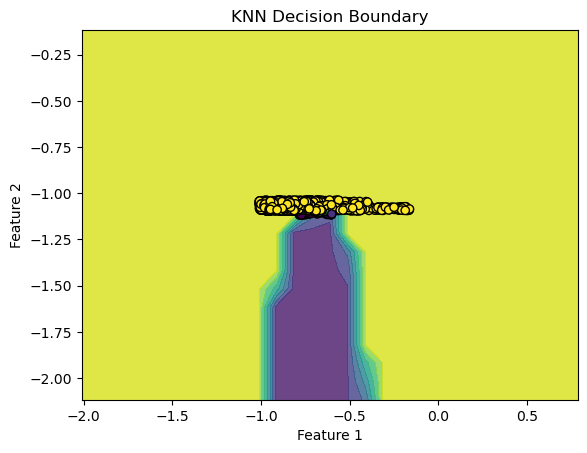

In [29]:
# Select the first two features for visualization
X_train_2d = X_train.iloc[:, :2]  # First two columns (features)

# Train KNN on just the first two features
knn.fit(X_train_2d, y_train)

# Create a mesh grid of points for visualization (only for 2D data)
x_min, x_max = X_train_2d.iloc[:, 0].min() - 1, X_train_2d.iloc[:, 0].max() + 1
y_min, y_max = X_train_2d.iloc[:, 1].min() - 1, X_train_2d.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Make predictions for each point in the meshgrid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X_train_2d.iloc[:, 0], X_train_2d.iloc[:, 1], c=y_train, edgecolors='k', marker='o')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KNN Decision Boundary")
plt.show()

C:\Users\hi448116\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


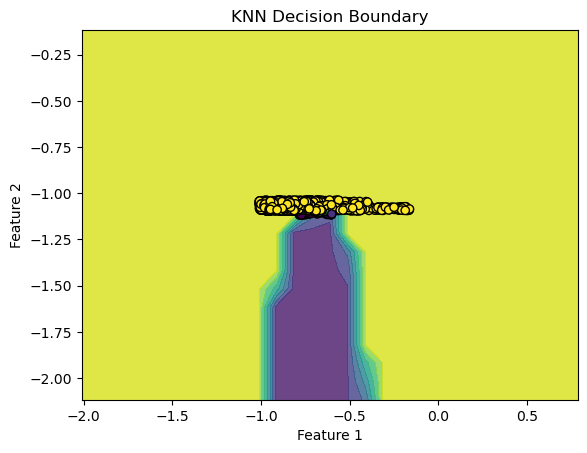

In [12]:
import matplotlib.pyplot as plt  # Import the missing library
import numpy as np

# Select the first two features for visualization
X_train_2d = X_train.iloc[:, :2]  # First two columns (features)

# Train KNN on just the first two features
knn.fit(X_train_2d, y_train)

# Create a mesh grid of points for visualization (only for 2D data)
x_min, x_max = X_train_2d.iloc[:, 0].min() - 1, X_train_2d.iloc[:, 0].max() + 1
y_min, y_max = X_train_2d.iloc[:, 1].min() - 1, X_train_2d.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Make predictions for each point in the meshgrid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X_train_2d.iloc[:, 0], X_train_2d.iloc[:, 1], c=y_train, edgecolors='k', marker='o')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KNN Decision Boundary")
plt.show()


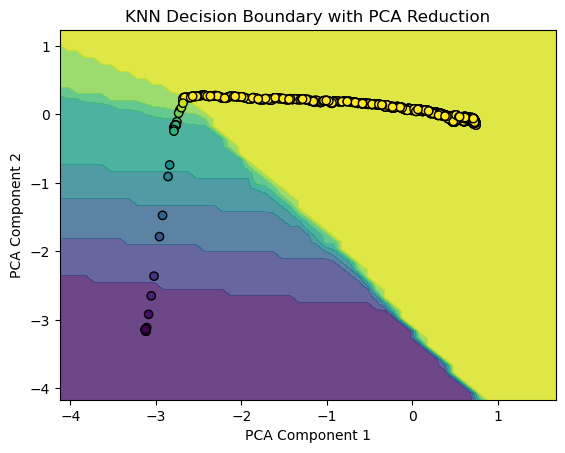

In [13]:
from sklearn.decomposition import PCA

# Reduce the dimensions of the data to 2 using PCA
pca = PCA(n_components=2)
X_train_2d_pca = pca.fit_transform(X_train)

# Train the model on the reduced 2D data
knn.fit(X_train_2d_pca, y_train)

# Create a mesh grid of points for visualization
x_min, x_max = X_train_2d_pca[:, 0].min() - 1, X_train_2d_pca[:, 0].max() + 1
y_min, y_max = X_train_2d_pca[:, 1].min() - 1, X_train_2d_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Make predictions for each point in the meshgrid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X_train_2d_pca[:, 0], X_train_2d_pca[:, 1], c=y_train, edgecolors='k', marker='o')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("KNN Decision Boundary with PCA Reduction")
plt.show()

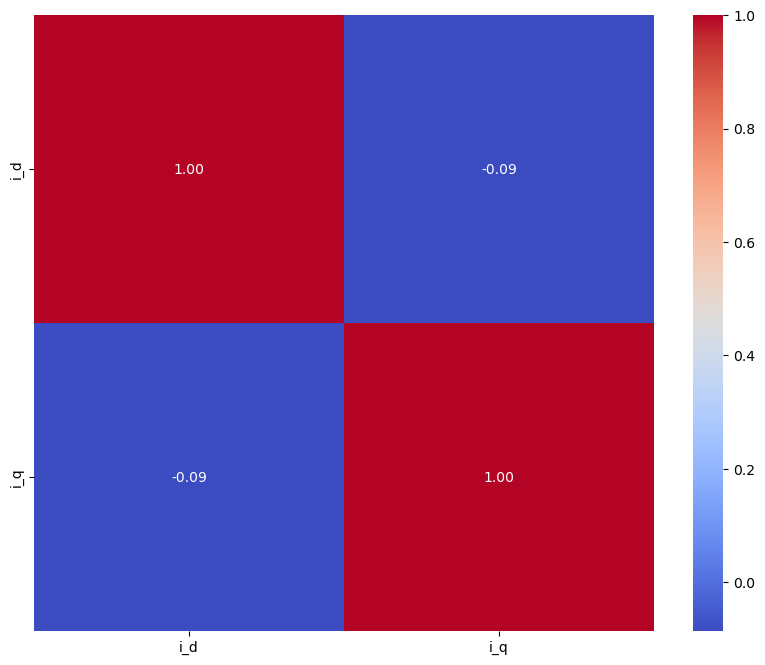

In [19]:
import seaborn as sns  # Import seaborn
import matplotlib.pyplot as plt  # Import matplotlib for plotting

# Assuming you have your DataFrame `df` already loaded and prepared
sd = pd.DataFrame()
sd['i_d'] = df['motor_speed']
sd['i_q'] = df['ambient']

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(sd.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()


In [ ]:
#Train the Decision Tree Model:

ambient           float64
coolant           float64
u_d               float64
u_q               float64
motor_speed       float64
torque            float64
i_d               float64
i_q               float64
pm                float64
stator_yoke       float64
stator_tooth      float64
stator_winding    float64
profile_id          int64
dtype: object


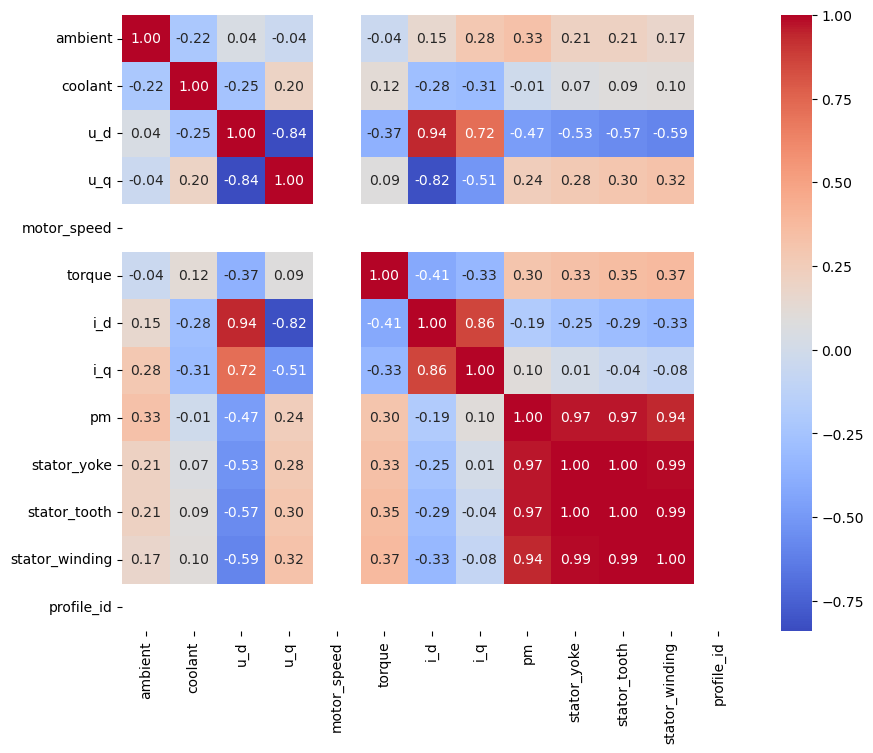

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r'D:\HI448116_Santosh_Karpe\FY25\DOCS\III\Ass\ASA - SK\Dataset and Objective-20250118T164825Z-001\Dataset and Objective\temperature_data (1).csv')


# Inspect the columns and data types
print(df.dtypes)

# Convert categorical variables (e.g., chest pain types) to numeric values
df['motor_speed'] = df['motor_speed'].map({
    'non-anginal': 0,
    'anginal': 1,
    'asymptomatic': 2,
    'typical angina': 3
})

# Select only numeric columns for correlation calculation
df_numeric = df.select_dtypes(include=['number'])

# Compute the correlation matrix
corr = df_numeric.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

# Show the plot
plt.show()

ambient           float64
coolant           float64
u_d               float64
u_q               float64
motor_speed       float64
torque            float64
i_d               float64
i_q               float64
pm                float64
stator_yoke       float64
stator_tooth      float64
stator_winding    float64
profile_id          int64
dtype: object
Index(['ambient', 'coolant', 'u_d', 'u_q', 'motor_speed', 'torque', 'i_d',
       'i_q', 'pm', 'stator_yoke', 'stator_tooth', 'stator_winding',
       'profile_id'],
      dtype='object')


<Axes: >

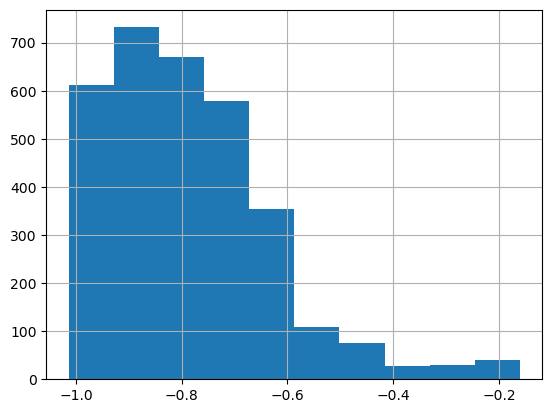

In [22]:
import pandas as pd

# Assuming df is your DataFrame
# Step 1: Check the data type of the column
print(df.dtypes)

# Step 2: Convert the column to numeric or datetime if needed
df['ambient'] = pd.to_numeric(df['ambient'], errors='coerce')  # for numeric data

# or if it's a date column
# df['column_name'] = pd.to_datetime(df['column_name'], errors='coerce')  # for date data
print(df.columns)
# Step 3: Plot the histogram again
df['ambient'].hist()

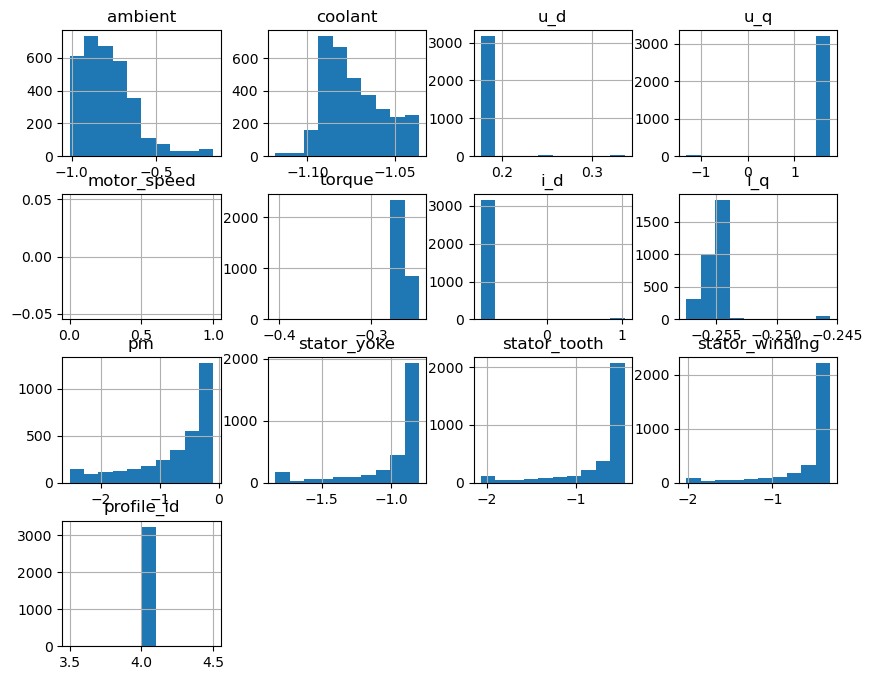

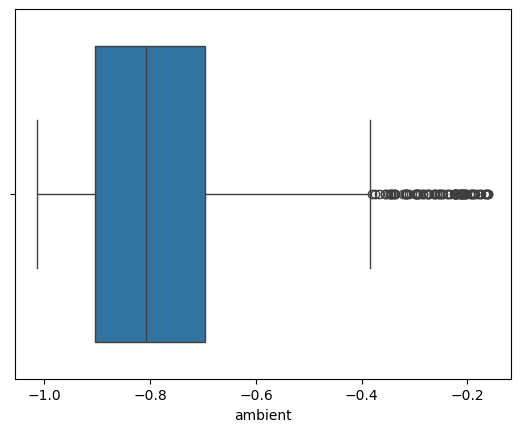

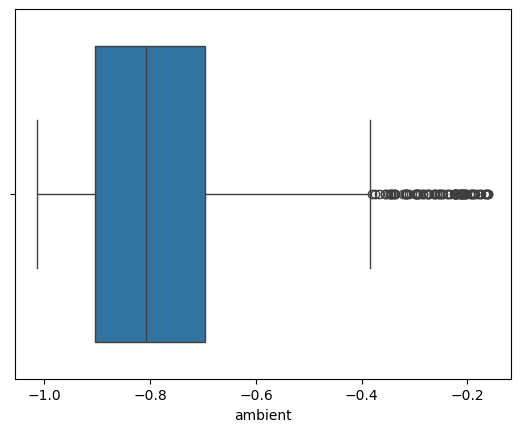

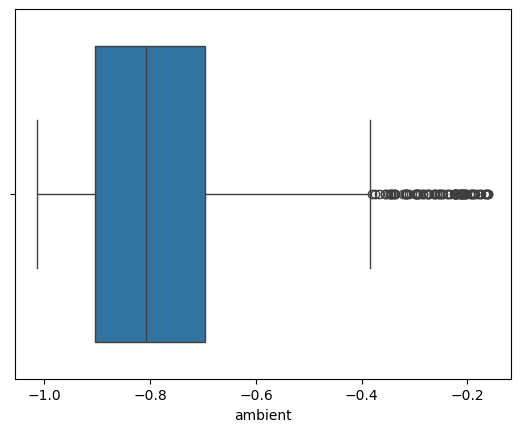

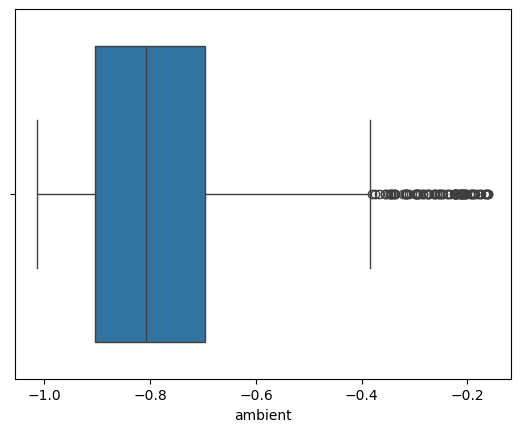

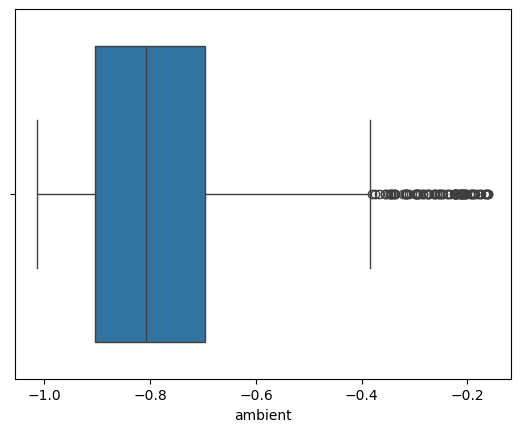

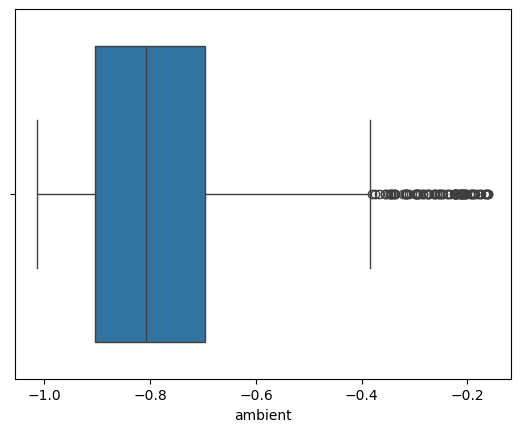

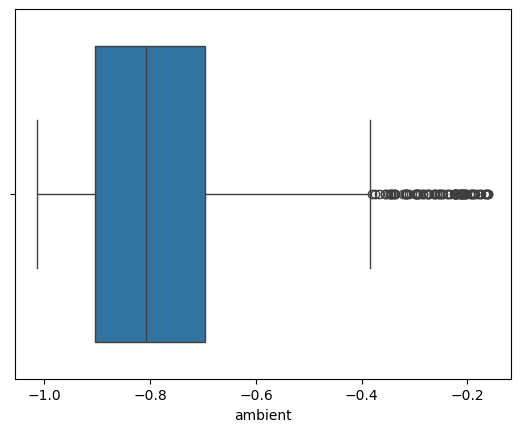

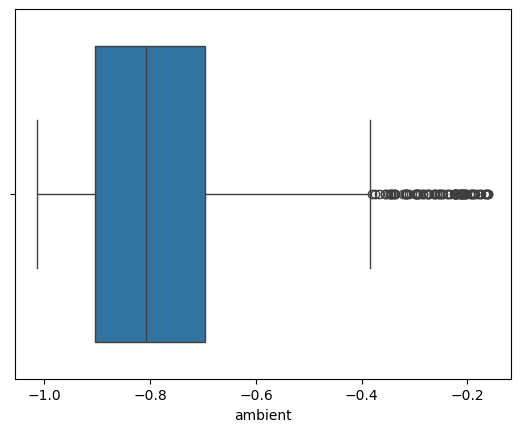

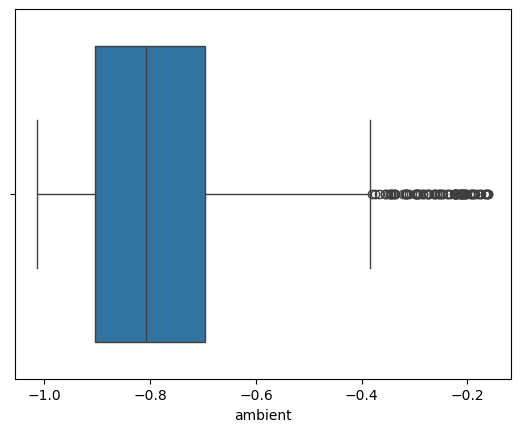

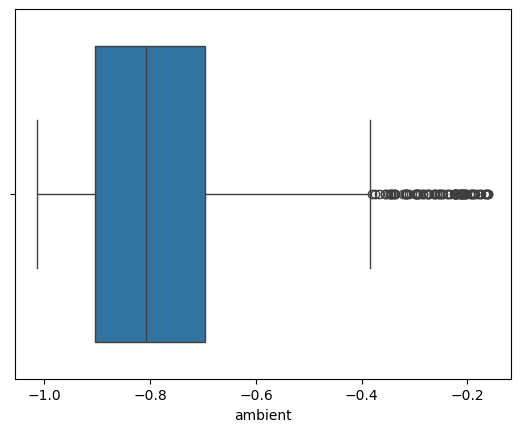

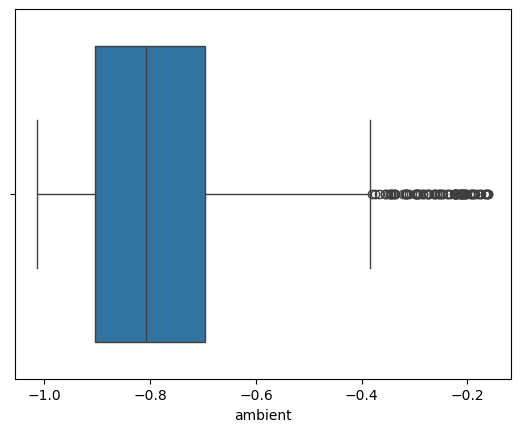

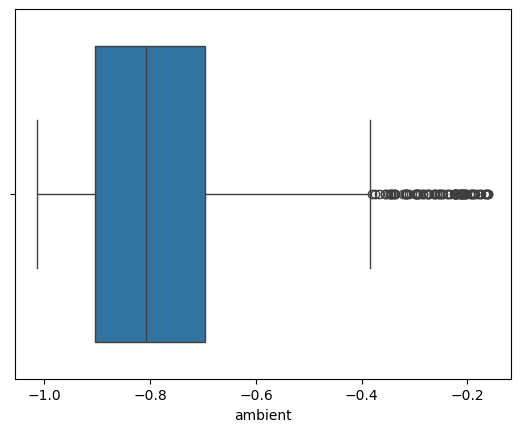

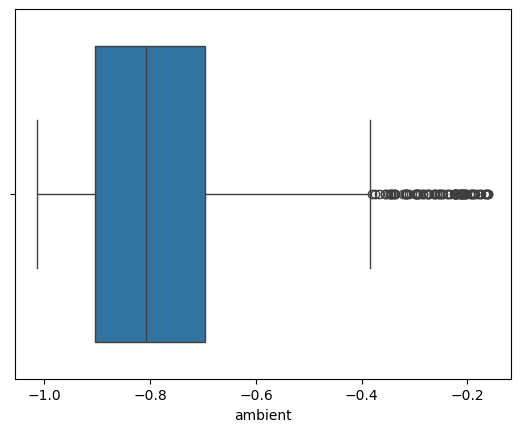

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot histograms for all features
df.hist(figsize=(10, 8))
plt.show()

# Boxplots to check for outliers
for column in df.select_dtypes(include=['float64', 'int64']).columns:
    sns.boxplot(x=df['ambient'])
    plt.show()

In [32]:
import pandas as pd
from sklearn.impute import SimpleImputer
import numpy as np
arr = None  # Invalid argument
np.array(arr)  # This will raise the error

# Load dataset
data = pd.read_csv(r'D:\HI448116_Santosh_Karpe\FY25\DOCS\III\Ass\ASA - SK\Dataset and Objective-20250118T164825Z-001\Dataset and Objective\temperature_data (1).csv')

# Identify missing values
missing_values = data.isnull().sum()

# Impute missing values (mean for numerical, mode for categorical)
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = data.select_dtypes(include=['object']).columns

imputer = SimpleImputer(strategy='mean')  # For numerical columns
data[numerical_cols] = imputer.fit_transform(data[numerical_cols])

imputer = SimpleImputer(strategy='most_frequent') 
# For categorical columns
#data[categorical_cols] = imputer.fit_transform(data[categorical_cols])

In [33]:
from scipy import stats
import numpy as np

# Remove outliers using Z-score method
data = data[(np.abs(stats.zscore(data[numerical_cols])) < 3).all(axis=1)]

In [35]:
from sklearn.preprocessing import StandardScaler

# Check the numerical columns
print("Numerical columns:", numerical_cols)

# Check for empty data or NaNs
print(data[numerical_cols].isna().sum())  # Check for missing values

# Optionally fill missing values (if any)
data[numerical_cols] = data[numerical_cols].fillna(0)

# If the columns are not empty, scale the data
if not data[numerical_cols].empty:
    scaler = StandardScaler()
    data[numerical_cols] = scaler.fit_transform(data[numerical_cols])
else:
    print("No valid data to scale.")


Numerical columns: Index(['ambient', 'coolant', 'u_d', 'u_q', 'motor_speed', 'torque', 'i_d',
       'i_q', 'pm', 'stator_yoke', 'stator_tooth', 'stator_winding',
       'profile_id'],
      dtype='object')
ambient           0
coolant           0
u_d               0
u_q               0
motor_speed       0
torque            0
i_d               0
i_q               0
pm                0
stator_yoke       0
stator_tooth      0
stator_winding    0
profile_id        0
dtype: int64
No valid data to scale.


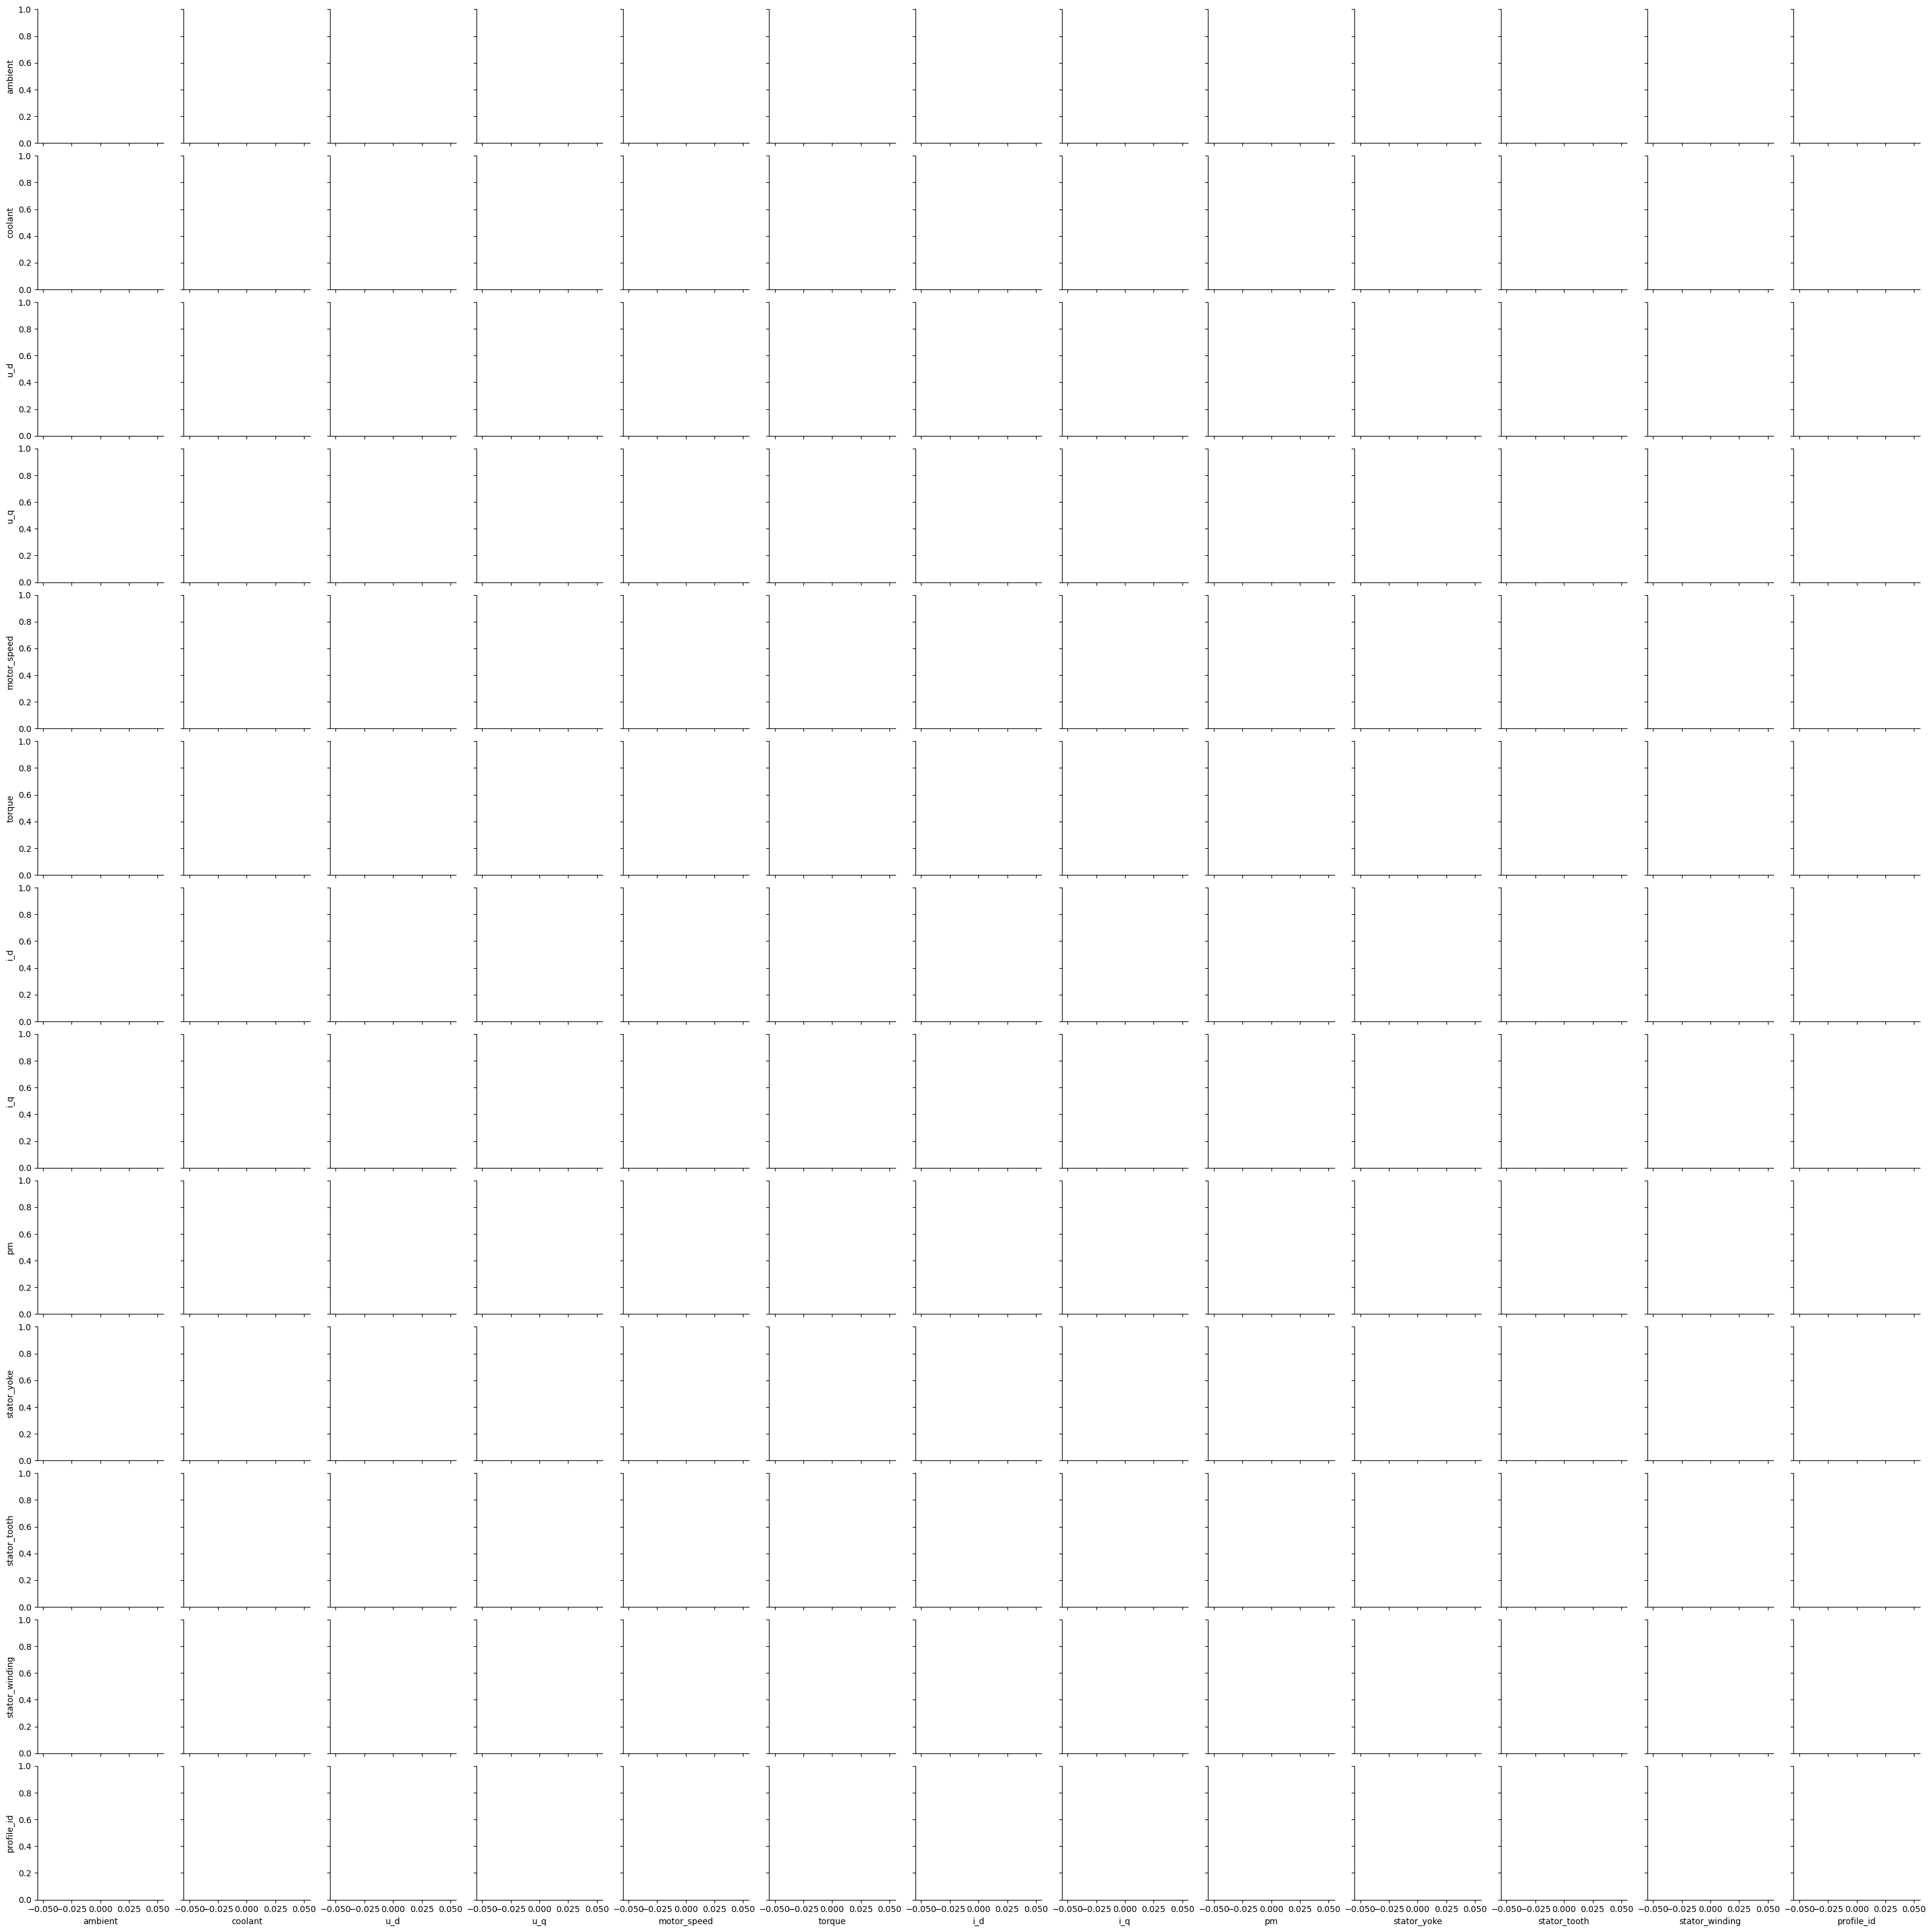

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(data[numerical_cols])
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


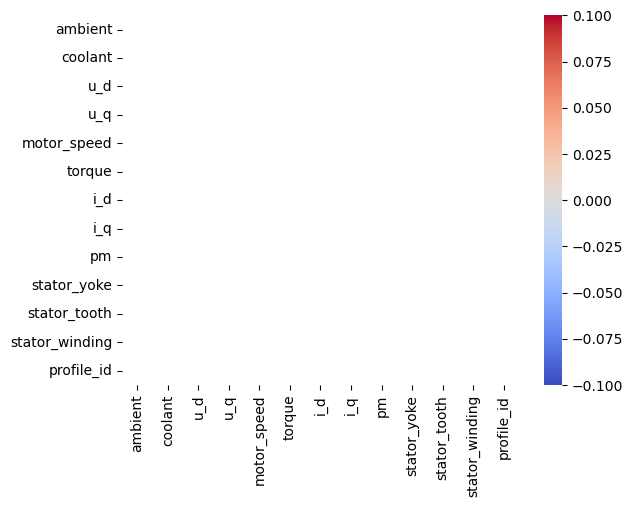

In [37]:
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# Implementing Clustering Algorithms
# K-Means Clustering
# K-Means clustering works by partitioning the data into K clusters. 
# The number of clusters K can be chosen using the Elbow Method or Silhouette Scores.